<a href="https://colab.research.google.com/github/umiSirya/imdb_data_science_pipeline/blob/main/imdb_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

import re



In [11]:
# load files
basics = pd.read_csv('title.basics.tsv', sep='\t', low_memory = False)
ratings = pd.read_csv('title.ratings.tsv', sep='\t')

basics.shape
ratings.shape


(1670824, 3)

In [12]:

# Merge on the title ID column
df = basics.merge(ratings, on="tconst")

# Filter to movies only, with decent votes and rating
df = df[
    (df["titleType"] == "movie") &
    (df["numVotes"] >= 25000) &
    (df["averageRating"] >= 7.0)
]

# Keep only the columns we need and rename them
df = df[[
    "tconst", "primaryTitle", "startYear",
    "runtimeMinutes", "genres", "averageRating", "numVotes"
]].rename(columns={
    "primaryTitle":   "title",
    "startYear":      "year",
    "runtimeMinutes": "runtime_min",
    "averageRating":  "rating",
    "numVotes":       "votes",
})

# Replace IMDB's null placeholder with proper NaN
df.replace("\\N", pd.NA, inplace=True)

# Sort by rating + votes to get the best movies
df = df.sort_values(["rating", "votes"], ascending=False).head(250).reset_index(drop=True)
df["rank"] = df.index + 1

print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

df.to_csv("imdb_raw.csv", index=False)
print("\nSaved to imdb_raw.csv!")

       tconst                                              title  year  \
0   tt0111161                           The Shawshank Redemption  1994   
1   tt0068646                                      The Godfather  1972   
2   tt0468569                                    The Dark Knight  2008   
3   tt0252487                                    The Chaos Class  1975   
4   tt0167260      The Lord of the Rings: The Return of the King  2003   
5   tt0108052                                   Schindler's List  1993   
6   tt0071562                              The Godfather Part II  1974   
7   tt0050083                                       12 Angry Men  1957   
8   tt0120737  The Lord of the Rings: The Fellowship of the Ring  2001   
9  tt11989890           David Attenborough: A Life on Our Planet  2020   

  runtime_min                   genres  rating    votes  rank  
0         142                    Drama     9.3  3189547     1  
1         175              Crime,Drama     9.2  2226753  

In [13]:
# load the csv file

dp = pd.read_csv('imdb_raw.csv')
dp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   tconst       250 non-null    object 
 1   title        250 non-null    object 
 2   year         250 non-null    int64  
 3   runtime_min  250 non-null    int64  
 4   genres       250 non-null    object 
 5   rating       250 non-null    float64
 6   votes        250 non-null    int64  
 7   rank         250 non-null    int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 15.8+ KB


# **Data cleaning**

In [14]:
# remove duplicates

print(f"Before dedup: {df.shape}")
df.drop_duplicates(subset="tconst", inplace=True)
print(f"After dedup:  {df.shape}")

# data has no duplicates

Before dedup: (250, 8)
After dedup:  (250, 8)


In [15]:
# fixing the votes threshold removing the movies with few votes
print('Movies under 100k votes')
print(df[df['votes']<100000][['title','year','rating','votes']])

df = df[df['votes']>=100000].reset_index(drop = True)
df['rank'] = df.index + 1
print('After filter votes:{df.shape}')

Movies under 100k votes
                                                 title  year  rating  votes
3                                      The Chaos Class  1975     9.1  46214
9             David Attenborough: A Life on Our Planet  2020     8.9  36122
10                                         Tosun Pasha  1976     8.9  26387
35                                            Harakiri  1962     8.6  91192
36                                          Anbe Sivam  2003     8.6  28280
37                                             Nayakan  1987     8.6  27862
58                                          Sita Ramam  2022     8.5  83828
59    Dear Zachary: A Letter to a Son About His Father  2008     8.5  45660
60                                              Baraka  1992     8.5  43183
61                                 Sarpatta Parambarai  2021     8.5  28611
80                                               Senna  2010     8.4  83955
81                                        High and Low  1963    

In [16]:
# STEP 3: Clean the genres column
# Extract just the first genre

df["primary_genre"] = df["genres"].str.split(",").str[0].str.strip()

print(f"Genre distribution:")
print(df["primary_genre"].value_counts())

Genre distribution:
primary_genre
Drama        59
Action       38
Adventure    34
Crime        33
Biography    20
Comedy       19
Horror        3
Animation     2
Mystery       1
Name: count, dtype: int64


In [17]:
# STEP 4: Feature engineering

# Convert runtime_min to integer first
df["runtime_min"] = pd.to_numeric(df["runtime_min"], errors="coerce")

# Convert year to integer first
df["year"] = pd.to_numeric(df["year"], errors="coerce")

# Decade — group years into 1950s, 1960s etc
df["decade"] = (df["year"] // 10 * 10).astype(str) + "s"

# Runtime category — short, normal, long
def classify_runtime(mins):
    if mins < 100:
        return "short"
    elif mins <= 150:
        return "normal"
    else:
        return "long"

df["runtime_category"] = df["runtime_min"].apply(classify_runtime)

# Is classic — movies before 1980
df["is_classic"] = df["year"] < 1980

# Votes in millions — easier to read on charts
df["votes_millions"] = (df["votes"] / 1_000_000).round(2)



In [18]:
# STEP 5: Final check

print("\n--- Final cleaned dataframe ---")
print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nNew columns preview:")
print(df[["title", "decade", "runtime_category", "is_classic", "votes_millions"]].head(10))

# Save to a csv file
df.to_csv("imdb_clean.csv", index=False)
print("\nSaved to imdb_clean.csv!")


--- Final cleaned dataframe ---
      tconst                                              title  year  \
0  tt0111161                           The Shawshank Redemption  1994   
1  tt0068646                                      The Godfather  1972   
2  tt0468569                                    The Dark Knight  2008   
3  tt0167260      The Lord of the Rings: The Return of the King  2003   
4  tt0108052                                   Schindler's List  1993   
5  tt0071562                              The Godfather Part II  1974   
6  tt0050083                                       12 Angry Men  1957   
7  tt0120737  The Lord of the Rings: The Fellowship of the Ring  2001   
8  tt1375666                                          Inception  2010   
9  tt0137523                                         Fight Club  1999   

   runtime_min                   genres  rating    votes  rank primary_genre  \
0          142                    Drama     9.3  3189547     1         Drama   
1  

In [23]:

# style for charts
sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)

# **Distribution of Ratings**


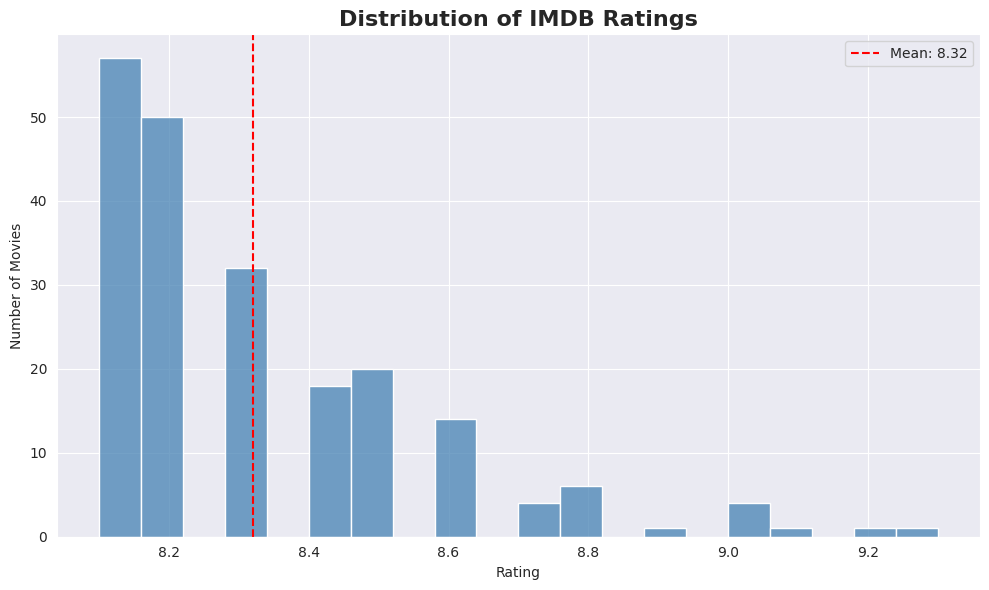

In [24]:

plt.figure(figsize=(10, 6))
sns.histplot(df["rating"], bins=20, color="steelblue", edgecolor="white")
plt.title("Distribution of IMDB Ratings", fontsize=16, fontweight="bold")
plt.xlabel("Rating")
plt.ylabel("Number of Movies")
plt.axvline(df["rating"].mean(), color="red", linestyle="--", label=f'Mean: {df["rating"].mean():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

# **Average Rating by Genre**

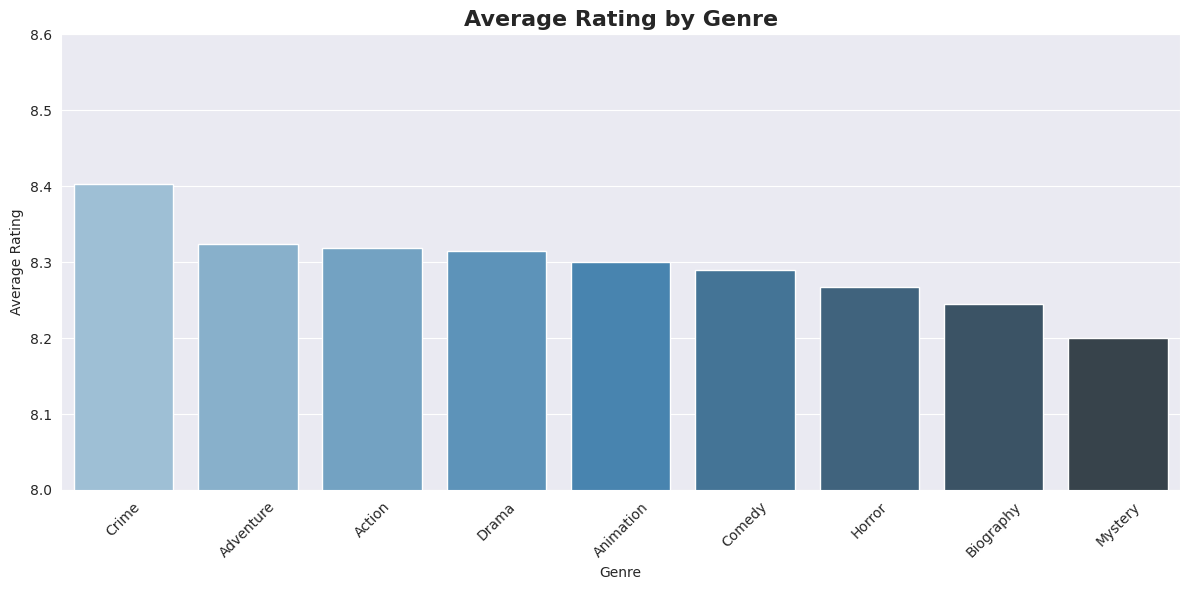

In [26]:
# Average Rating by Genre

genre_rating = df.groupby("primary_genre")["rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_rating.index, y=genre_rating.values,
            hue=genre_rating.index, palette="Blues_d", legend=False)
plt.title("Average Rating by Genre", fontsize=16, fontweight="bold")
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.ylim(8.0, 8.6)  # This zooms in so differences are visible
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Movies by Decade**

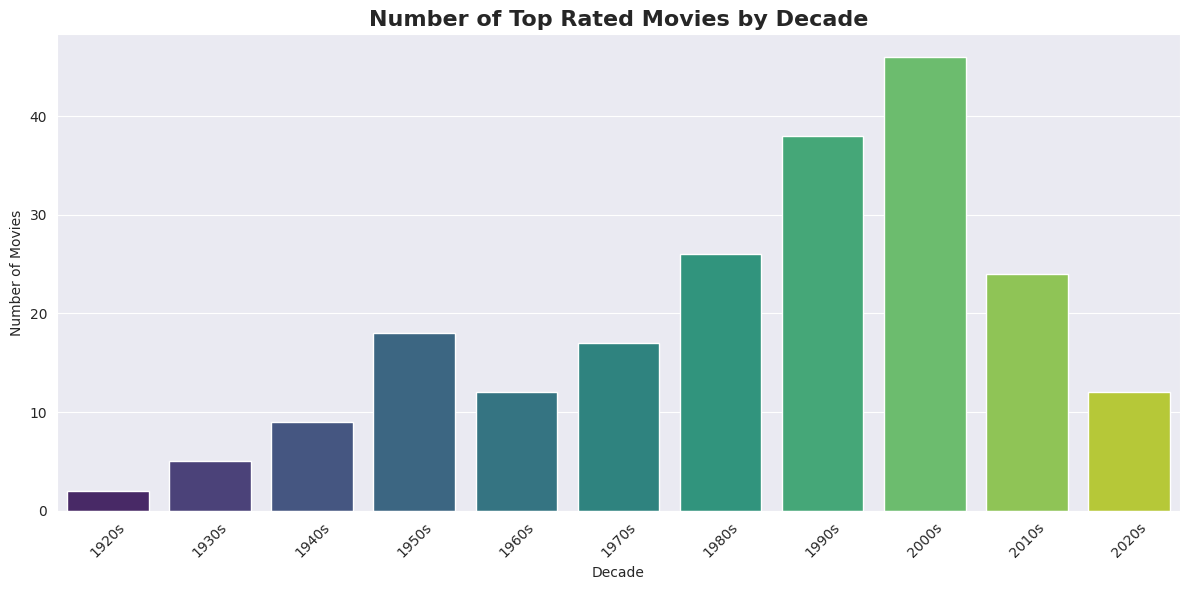

In [27]:
decade_count = df.groupby("decade")["title"].count().reset_index()
decade_count.columns = ["decade", "count"]

plt.figure(figsize=(12, 6))
sns.barplot(x="decade", y="count", data=decade_count,
            hue="decade", palette="viridis", legend=False)
plt.title("Number of Top Rated Movies by Decade", fontsize=16, fontweight="bold")
plt.xlabel("Decade")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Movies by Decade**

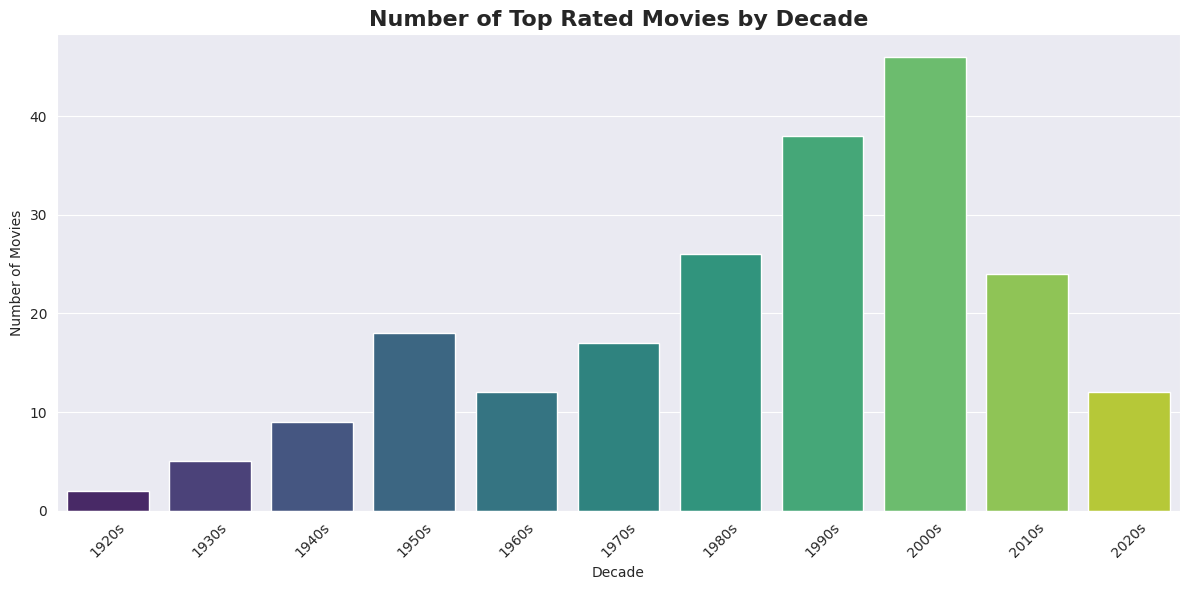

In [28]:
decade_count = df.groupby("decade")["title"].count().sort_index()

plt.figure(figsize=(12, 6))
sns.barplot(x=decade_count.index, y=decade_count.values,
            hue=decade_count.index, palette="viridis", legend=False)
plt.title("Number of Top Rated Movies by Decade", fontsize=16, fontweight="bold")
plt.xlabel("Decade")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Rating vs Votes**

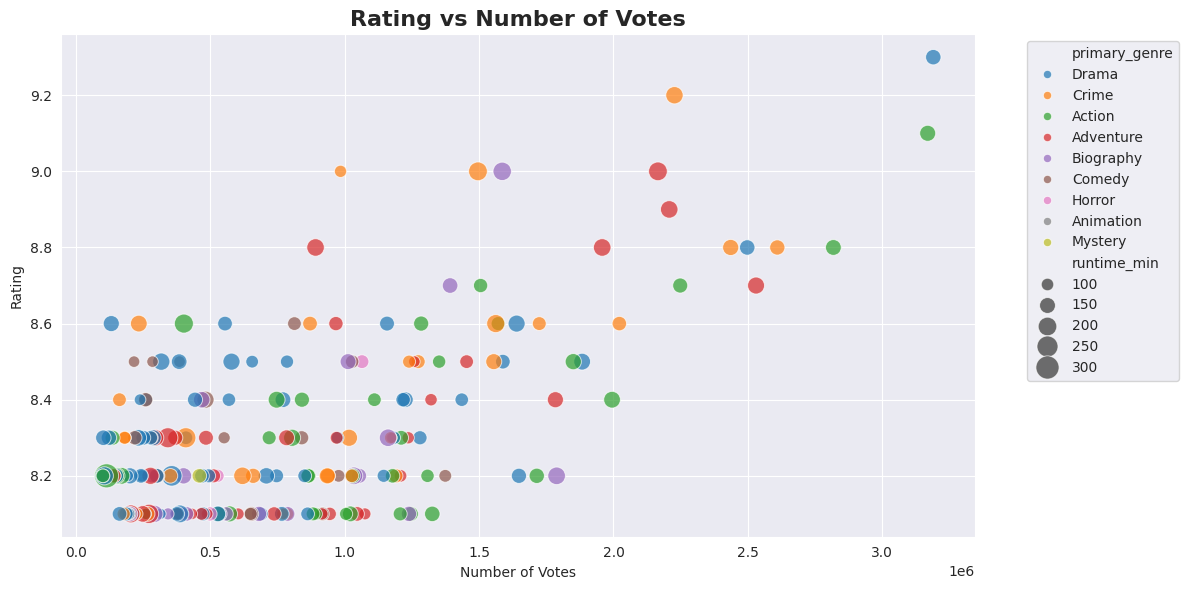

In [29]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x="votes", y="rating",
                hue="primary_genre", size="runtime_min",
                sizes=(50, 300), alpha=0.7)
plt.title("Rating vs Number of Votes", fontsize=16, fontweight="bold")
plt.xlabel("Number of Votes")
plt.ylabel("Rating")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# **Runtime Distribution by Genre**

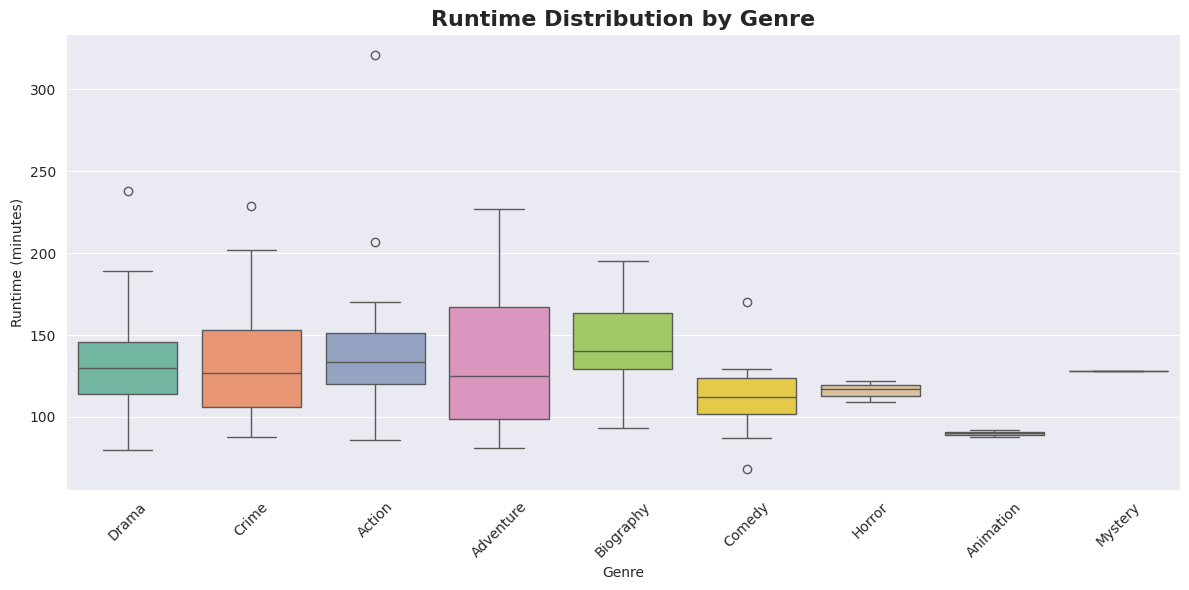

In [30]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="primary_genre", y="runtime_min",
            hue="primary_genre", palette="Set2", legend=False)
plt.title("Runtime Distribution by Genre", fontsize=16, fontweight="bold")
plt.xlabel("Genre")
plt.ylabel("Runtime (minutes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()